# Análisis de Fijaciones — Matrices Progresivas (Eye-Tracking)

Este notebook toma los datos corregidos de `01_offset_correction.ipynb` y realiza:

1. **Detección de fijaciones** con el algoritmo I-DT (gold-standard)
2. **Cálculo de métricas** por trial (fijación, dwell time, estrategia, RQA)
3. **Filtrado de outliers** automático (IQR) y manual
4. **Diagnóstico visual** de calidad de detección

---

### Cómo agregar nuevas métricas

La Sección 4 está organizada en **bloques independientes**, uno por tipo de métrica.
Para agregar una nueva métrica:
1. Agregá un bloque nuevo dentro del loop principal (marcado con `# === NUEVO BLOQUE ===`)
2. Agregá la clave correspondiente en el diccionario `trial_record` al final del loop
3. Si necesita pre-cálculo fuera del loop, agregalo en la Fase 1 o Fase 2

---

**Input:** `corrected_data` (de `01_offset_correction.ipynb`)  
**Output:** `df_analisis` — DataFrame con métricas por trial, listo para análisis estadístico

## 0. Imports y funciones del script principal

In [4]:
import os
import sys
import json
import re
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy.spatial.distance import euclidean
from scipy.ndimage import gaussian_filter
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

# Agregar el directorio raíz al path para importar el módulo de detección
sys.path.append(os.path.join(os.getcwd(), '..'))
from src.fixation_detection import (
    FixationDetectionConfig,
    detect_fixations_complete,
    fixations_to_records,
    CONFIG_DEFAULT
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
COLOR_PALETTE = {'Medio': '#3274A1', 'Bajo': '#E1812C'}

print('Imports OK.')

Imports OK.


## 1. Configuración

Todos los parámetros editables están acá. **Tocá solo esta celda** entre sesiones.

In [5]:
# ---------------------------------------------------------------------------
# PARÁMETROS DE DETECCIÓN DE FIJACIONES
# ---------------------------------------------------------------------------
FIXATION_CONFIG = FixationDetectionConfig(
    dispersion_threshold = 0.025,   # ~1.25° de ángulo visual
    min_duration_ms      = 100,     # 100ms — estándar para scene viewing
    min_samples          = 6,       # ~100ms a 60Hz
    velocity_threshold   = 0.0008,  # ~40°/s
    use_velocity_filter  = True,
    merge_threshold_ms   = 75,
    merge_dispersion_factor = 1.5,
    max_interpolation_gap_ms = 75,
)

# ---------------------------------------------------------------------------
# PARÁMETROS DE RQA
# ---------------------------------------------------------------------------
RQA_RADIUS      = 0.05   # Radio de recurrencia (coordenadas normalizadas)
N_SURROGATES    = 100    # 100 para desarrollo, 1000 para publicación
RQA_SEED        = 42     # Semilla para reproducibilidad

# ---------------------------------------------------------------------------
# FILTRADO DE OUTLIERS (Sección 5)
# ---------------------------------------------------------------------------
APLICAR_FILTRO_IQR  = True
METRICA_FILTRADO    = 'total_dwell_time_s'
IQR_MULTIPLIER      = 2.0

PARTICIPANTES_A_EXCLUIR = [
    '1f628f193a',
    '3fe6018002',
    '4f65b09d88',
    '5b76ecccbd',
    '5d900daa03',
    '9d39c08bc3',
    '227a79250b',
    '413e19c92b',
    'a7ec7bb6ad',
]

print('Configuración cargada.')
print(f'  dispersion_threshold : {FIXATION_CONFIG.dispersion_threshold}')
print(f'  min_duration_ms      : {FIXATION_CONFIG.min_duration_ms} ms')
print(f'  min_samples          : {FIXATION_CONFIG.min_samples}')
print(f'  velocity_filter      : {FIXATION_CONFIG.use_velocity_filter}')
print(f'  RQA radius           : {RQA_RADIUS}')
print(f'  N surrogates         : {N_SURROGATES}')
print(f'  Participantes a excluir: {len(PARTICIPANTES_A_EXCLUIR)}')

Configuración cargada.
  dispersion_threshold : 0.025
  min_duration_ms      : 100 ms
  min_samples          : 6
  velocity_filter      : True
  RQA radius           : 0.05
  N surrogates         : 100
  Participantes a excluir: 9


## 2. AOIs, respuestas correctas y funciones auxiliares

Definición de las Areas of Interest, la clasificación de errores, y todas las funciones
de asignación semántica que usa el loop de métricas.

In [6]:
AOIS = {
    'A':  (0.25, 0.025, 0.49, 0.255), 'B':  (0.49, 0.025, 0.75, 0.255),
    'C':  (0.25, 0.255, 0.49, 0.485), 'D':  (0.49, 0.255, 0.75, 0.485),
    'R1': (0.20, 0.535, 0.39, 0.770), 'R2': (0.39, 0.535, 0.58, 0.770),
    'R3': (0.58, 0.535, 0.77, 0.770), 'R4': (0.20, 0.770, 0.39, 0.985),
    'R5': (0.39, 0.770, 0.58, 0.985), 'R6': (0.58, 0.770, 0.77, 0.985),
}

CORRECT_ANSWERS = {
    1:'R4', 2:'R5', 3:'R1', 4:'R2', 5:'R6', 6:'R3', 7:'R6', 8:'R2', 9:'R1',
    10:'R3', 11:'R4', 12:'R5', 13:'R4', 14:'R5', 15:'R1', 16:'R6', 17:'R2',
    18:'R1', 19:'R3', 20:'R4', 21:'R6', 22:'R3', 23:'R5', 24:'R2', 25:'R2',
    26:'R6', 27:'R1', 28:'R2', 29:'R1', 30:'R3', 31:'R5', 32:'R6', 33:'R4',
    34:'R3', 35:'R6', 36:'R6'
}

PROBLEMA_AOIS  = ['A', 'B', 'C', 'D']
RESPUESTA_AOIS = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6']

INCORRECT_CLASSIFICATION = {
    1:  {'Co':'R4', 'SimF':{'R2','R6'},      'DisF':{'R1','R3','R5'}},
    2:  {'Co':'R5', 'SimF':set(),            'DisF':{'R1','R2','R3','R4','R6'}},
    3:  {'Co':'R1', 'SimF':{'R3'},           'DisF':{'R2','R4','R5','R6'}},
    4:  {'Co':'R2', 'SimF':{'R3'},           'DisF':{'R1','R4','R5','R6'}},
    5:  {'Co':'R6', 'SimF':set(),            'DisF':{'R1','R2','R3','R4','R5'}},
    6:  {'Co':'R3', 'SimF':{'R1','R2'},      'DisF':{'R4','R5','R6'}},
    7:  {'Co':'R6', 'SimF':{'R4'},           'DisF':{'R1','R2','R3','R5'}},
    8:  {'Co':'R2', 'SimF':{'R1','R6'},      'DisF':{'R3','R4','R5'}},
    9:  {'Co':'R1', 'SimF':{'R2','R5'},      'DisF':{'R3','R4','R6'}},
    10: {'Co':'R3', 'SimF':{'R6'},           'DisF':{'R1','R2','R4','R5'}},
    11: {'Co':'R4', 'SimF':{'R1','R2'},      'DisF':{'R3','R5','R6'}},
    12: {'Co':'R5', 'SimF':{'R6'},           'DisF':{'R1','R2','R3','R4'}},
    13: {'Co':'R4', 'SimF':{'R2'},           'DisF':{'R1','R3','R5','R6'}},
    14: {'Co':'R5', 'SimF':{'R2','R4'},      'DisF':{'R1','R3','R6'}},
    15: {'Co':'R1', 'SimF':{'R5'},           'DisF':{'R2','R3','R4','R6'}},
    16: {'Co':'R6', 'SimF':{'R1','R4'},      'DisF':{'R2','R3','R5'}},
    17: {'Co':'R2', 'SimF':{'R1','R3'},      'DisF':{'R4','R5','R6'}},
    18: {'Co':'R1', 'SimF':{'R2','R3'},      'DisF':{'R4','R5','R6'}},
    19: {'Co':'R3', 'SimF':{'R2'},           'DisF':{'R1','R4','R5','R6'}},
    20: {'Co':'R4', 'SimF':{'R2','R5'},      'DisF':{'R1','R3','R6'}},
    21: {'Co':'R6', 'SimF':{'R2','R3'},      'DisF':{'R1','R4','R5'}},
    22: {'Co':'R3', 'SimF':{'R6'},           'DisF':{'R1','R2','R4','R5'}},
    23: {'Co':'R5', 'SimF':{'R3'},           'DisF':{'R1','R2','R4','R6'}},
    24: {'Co':'R2', 'SimF':{'R4','R5'},      'DisF':{'R1','R3','R6'}},
    25: {'Co':'R2', 'SimF':set(),            'DisF':{'R1','R3','R4','R5','R6'}},
    26: {'Co':'R6', 'SimF':{'R2','R3'},      'DisF':{'R1','R4','R5'}},
    27: {'Co':'R1', 'SimF':{'R2','R3'},      'DisF':{'R4','R5','R6'}},
    28: {'Co':'R2', 'SimF':set(),            'DisF':{'R1','R3','R4','R5','R6'}},
    29: {'Co':'R1', 'SimF':{'R2','R5'},      'DisF':{'R3','R4','R6'}},
    30: {'Co':'R3', 'SimF':{'R2'},           'DisF':{'R1','R4','R5','R6'}},
    31: {'Co':'R5', 'SimF':{'R1'},           'DisF':{'R2','R3','R4','R6'}},
    32: {'Co':'R6', 'SimF':{'R5'},           'DisF':{'R1','R2','R3','R4'}},
    33: {'Co':'R4', 'SimF':{'R2'},           'DisF':{'R1','R3','R5','R6'}},
    34: {'Co':'R3', 'SimF':{'R2'},           'DisF':{'R1','R4','R5','R6'}},
    35: {'Co':'R4', 'SimF':{'R2','R3'},      'DisF':{'R1','R5','R6'}},
    36: {'Co':'R5', 'SimF':{'R2','R3'},      'DisF':{'R1','R4','R6'}},
}

ADJACENCY_MAP = {
    'R1':{'R2','R4'}, 'R2':{'R1','R3','R5'}, 'R3':{'R2','R6'},
    'R4':{'R1','R5'}, 'R5':{'R2','R4','R6'}, 'R6':{'R3','R5'},
}

print(f'AOIs definidas: {list(AOIS.keys())}')
print(f'Ítems con respuesta correcta definida: {len(CORRECT_ANSWERS)}')

AOIs definidas: ['A', 'B', 'C', 'D', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6']
Ítems con respuesta correcta definida: 36


In [7]:
# ---------------------------------------------------------------------------
# Funciones de asignación de AOI y clasificación semántica
# ---------------------------------------------------------------------------

def get_aoi(x, y):
    """Devuelve el nombre de la AOI que contiene el punto (x, y), o 'Outside'."""
    for name, (xmin, ymin, xmax, ymax) in AOIS.items():
        if xmin <= x <= xmax and ymin <= y <= ymax:
            return name
    return 'Outside'

def get_aoi_type(aoi_name):
    """Clasifica una AOI como 'matrix', 'options' u 'outside'."""
    if aoi_name in PROBLEMA_AOIS:  return 'matrix'
    if aoi_name in RESPUESTA_AOIS: return 'options'
    return 'outside'

def get_semantic_aoi(aoi_name, trial_num):
    """Clasifica una AOI como Problema / Correcto / Incorrectas / Outside."""
    if aoi_name in PROBLEMA_AOIS:                    return 'Problema'
    if aoi_name == CORRECT_ANSWERS.get(trial_num):   return 'Correcto'
    if aoi_name in RESPUESTA_AOIS:                   return 'Incorrectas'
    return 'Outside'

def cohen_d(g1, g2):
    """d de Cohen entre dos grupos."""
    if len(g1) < 2 or len(g2) < 2: return 0.0
    n1, n2 = len(g1), len(g2)
    v1, v2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
    if v1 == 0 and v2 == 0: return 0.0
    pooled = np.sqrt(((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2))
    return (np.mean(g1) - np.mean(g2)) / pooled if pooled > 0 else 0.0

def get_sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

print('Funciones auxiliares cargadas.')

Funciones auxiliares cargadas.


## 3. Cargar datos corregidos

Acá entra el output de `01_offset_correction.ipynb`.  
Si corriste ese notebook en la misma sesión, `corrected_data` ya está en memoria.  
Si no, cargalo desde el JSON guardado.

In [8]:
# Opción A: corrected_data ya está en memoria (misma sesión de Jupyter)
# → No hace falta hacer nada, seguí a la siguiente celda

# Opción B: cargar desde disco
CORRECTED_DATA_PATH = r'C:\Users\LENOVO L340\Documents\Trabajo\Período actual\Notebooks\data\corrected_gaze.json'
with open(CORRECTED_DATA_PATH, 'r', encoding='utf-8') as f:
    corrected_data = json.load(f)

# Verificación
assert 'corrected_data' in dir() or 'corrected_data' in globals(), \
    "corrected_data no está en memoria. Corré 01_offset_correction.ipynb primero, " \
    "o descomentá la Opción B para cargarlo desde disco."

n_participants = len(corrected_data)
n_trials_total = sum(len(p['trials']) for p in corrected_data.values())
n_points_total = sum(
    len(t['points'])
    for p in corrected_data.values()
    for t in p['trials'].values()
)

print(f'corrected_data cargado correctamente.')
print(f'  Participantes : {n_participants}')
print(f'  Trials totales: {n_trials_total}')
print(f'  Muestras de mirada: {n_points_total:,}')

corrected_data cargado correctamente.
  Participantes : 296
  Trials totales: 10656
  Muestras de mirada: 5,111,154


## 4. Funciones RQA

Cálculo de métricas de Recurrence Quantification Analysis (raw y normalizadas contra baseline).

In [9]:
def calculate_rqa_metrics(fixation_coords, radius=0.1, min_line=2):
    """
    Calcula métricas RQA sobre el triángulo superior de la matriz de recurrencia.
    
    Métricas: REC, DET, LAM, CORM, ENTR, Lmax, TT
    
    Returns dict con valores float (0.0 si no hay suficientes fijaciones).
    """
    N = len(fixation_coords)
    empty = {'REC':0.0,'DET':0.0,'LAM':0.0,'CORM':0.0,'ENTR':0.0,'Lmax':0.0,'TT':0.0}
    if N < min_line:
        return empty

    # Matriz de recurrencia — solo triángulo superior (excluye diagonal)
    rp = np.zeros((N, N), dtype=np.int8)
    for i in range(N):
        for j in range(i+1, N):
            if euclidean(fixation_coords[i], fixation_coords[j]) <= radius:
                rp[i, j] = 1

    R = np.sum(rp)
    N_pairs = N * (N - 1) // 2
    if R == 0 or N_pairs == 0:
        return empty

    REC = 100 * R / N_pairs

    # Líneas diagonales (DET, ENTR, Lmax)
    diag_lengths = []
    for k in range(1, N):
        diag = np.diagonal(rp, offset=k)
        for seq in ''.join(map(str, map(int, diag))).split('0'):
            if len(seq) >= min_line:
                diag_lengths.append(len(seq))

    diag_pts = sum(diag_lengths)
    DET  = 100 * diag_pts / R if R > 0 else 0.0
    Lmax = max(diag_lengths) if diag_lengths else 0
    if diag_lengths:
        ul, counts = np.unique(diag_lengths, return_counts=True)
        probs = counts / len(diag_lengths)
        ENTR = -np.sum(probs * np.log(probs + 1e-10))
    else:
        ENTR = 0.0

    # Líneas verticales (LAM, TT) — solo triángulo superior
    vert_lengths = []
    for j in range(1, N):
        col = rp[:j, j]
        for seq in ''.join(map(str, map(int, col))).split('0'):
            if len(seq) >= min_line:
                vert_lengths.append(len(seq))

    vert_pts = sum(vert_lengths)
    LAM = 100 * vert_pts / R if R > 0 else 0.0
    TT  = np.mean(vert_lengths) if vert_lengths else 0.0

    # CORM
    idx = np.argwhere(rp == 1)
    CORM = np.sum(idx[:,1] - idx[:,0]) / (R * (N-1)) if R > 0 and N > 1 else 0.0

    return {'REC':REC,'DET':DET,'LAM':LAM,'CORM':CORM,'ENTR':ENTR,'Lmax':Lmax,'TT':TT}

print('calculate_rqa_metrics() definida.')

calculate_rqa_metrics() definida.


In [10]:
def calculate_rqa_with_baseline(
    fixation_coords, radius=0.1, min_line=2,
    n_surrogates=100, method='shuffle',
    spatial_sampler=None, seed=None
):
    """
    Calcula métricas RQA normalizadas contra baseline aleatorio.
    
    Implementa Anderson et al. (2013): comparar RQA contra modelo aleatorio.
    
    Métodos de baseline:
    - 'shuffle'        : permutación aleatoria del orden de fijaciones
    - 'spatial_sample' : muestreo desde el heatmap espacial del ítem
    
    Returns dict con sufijos _raw, _z, _p, _surr_mean para cada métrica.
    """
    observed = calculate_rqa_metrics(fixation_coords, radius, min_line)

    # Sin datos suficientes → todo NaN
    if observed.get('REC', 0) == 0:
        result = {f'{k}_raw': v for k, v in observed.items()}
        result.update({f'{k}_z': np.nan for k in observed})
        result.update({f'{k}_p': np.nan for k in observed})
        result.update({f'{k}_surr_mean': np.nan for k in observed})
        result['baseline_method'] = method
        return result

    rng = np.random.default_rng(seed)
    surr = {k: [] for k in observed}
    coords_arr = np.array(fixation_coords)

    for _ in range(n_surrogates):
        if method == 'shuffle':
            sc = [tuple(coords_arr[i]) for i in rng.permutation(len(fixation_coords))]
        elif method == 'spatial_sample':
            sc = spatial_sampler(len(fixation_coords), rng) if spatial_sampler else \
                 [tuple(coords_arr[i]) for i in rng.permutation(len(fixation_coords))]
        else:
            raise ValueError(f'Método desconocido: {method}')

        s = calculate_rqa_metrics(sc, radius, min_line)
        for k, v in s.items():
            if not np.isnan(v):
                surr[k].append(v)

    results = {'baseline_method': method}
    for metric, obs_val in observed.items():
        sv = np.array(surr[metric])
        results[f'{metric}_raw'] = obs_val
        if len(sv) < 10:
            results[f'{metric}_z'] = np.nan
            results[f'{metric}_p'] = np.nan
            results[f'{metric}_surr_mean'] = np.nan
            continue
        sm, ss = np.mean(sv), np.std(sv)
        results[f'{metric}_z'] = (obs_val - sm) / ss if ss > 1e-10 else 0.0
        results[f'{metric}_p'] = float(np.mean(sv >= obs_val))
        results[f'{metric}_surr_mean'] = sm

    return results

print('calculate_rqa_with_baseline() definida.')

calculate_rqa_with_baseline() definida.


In [11]:
def create_spatial_sampler_from_heatmap(all_fixations_for_item, sigma=0.02, grid_size=50):
    """
    Crea un sampler espacial basado en el heatmap de fijaciones del ítem.
    Implementa el método de Anderson et al. (2013) para baseline espacialmente informado.
    """
    coords = np.array(all_fixations_for_item)
    if len(coords) < 10:
        def uniform_sampler(n, rng):
            return list(zip(rng.uniform(0,1,n), rng.uniform(0,1,n)))
        return uniform_sampler

    x_min, x_max = coords[:,0].min()-0.05, coords[:,0].max()+0.05
    y_min, y_max = coords[:,1].min()-0.05, coords[:,1].max()+0.05

    heatmap, x_edges, y_edges = np.histogram2d(
        coords[:,0], coords[:,1], bins=grid_size,
        range=[[x_min,x_max],[y_min,y_max]]
    )
    heatmap_smooth = gaussian_filter(heatmap.astype(float), sigma=sigma*grid_size)
    heatmap_smooth = np.maximum(heatmap_smooth, 1e-10)
    prob_flat = (heatmap_smooth / heatmap_smooth.sum()).flatten()

    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2
    bw_x = x_edges[1] - x_edges[0]
    bw_y = y_edges[1] - y_edges[0]

    def sampler(n, rng):
        flat_idx = rng.choice(len(prob_flat), size=n, p=prob_flat)
        ix, iy = flat_idx // grid_size, flat_idx % grid_size
        xs = x_centers[ix] + rng.uniform(-0.5,0.5,n)*bw_x
        ys = y_centers[iy] + rng.uniform(-0.5,0.5,n)*bw_y
        return list(zip(xs, ys))

    return sampler

print('create_spatial_sampler_from_heatmap() definida.')

create_spatial_sampler_from_heatmap() definida.


## 5. Sección 4: Cálculo de métricas

El loop principal está dividido en **fases y bloques independientes**.
Cada bloque calcula un tipo de métrica y la agrega al diccionario `trial_record`.

Para agregar nuevas métricas en el futuro:
- Agregá un bloque `# === BLOQUE: NOMBRE ===` dentro del loop
- Agregá las claves nuevas en `trial_record` al final del loop
- Si el cálculo necesita datos de todos los participantes primero, hacelo en la Fase 1

In [12]:
# =============================================================================
# FASE 1: Pre-cálculo de heatmaps por ítem
# (necesario para el baseline espacial de RQA)
# =============================================================================
print('FASE 1: Recolectando fijaciones por ítem para heatmaps...')

fixations_by_item = defaultdict(list)

for p_id, p_data in corrected_data.items():
    for trial_num, trial_data in p_data['trials'].items():
        points = trial_data.get('points', [])
        if len(points) >= FIXATION_CONFIG.min_samples:
            try:
                fix_objs = detect_fixations_complete(points, config=FIXATION_CONFIG)
                for f in fix_objs:
                    fixations_by_item[int(trial_num)].append((f.center_x, f.center_y))
            except Exception:
                pass

print(f'  Ítems con fijaciones recolectadas: {len(fixations_by_item)}')
print(f'  Total fijaciones pre-calculadas  : {sum(len(v) for v in fixations_by_item.values()):,}')

FASE 1: Recolectando fijaciones por ítem para heatmaps...
  Ítems con fijaciones recolectadas: 36
  Total fijaciones pre-calculadas  : 156,708


In [13]:
# =============================================================================
# FASE 2: Crear spatial samplers por ítem
# =============================================================================
print('FASE 2: Creando spatial samplers...')

spatial_samplers = {}
for trial_num, fix_list in sorted(fixations_by_item.items()):
    if len(fix_list) >= 20:
        spatial_samplers[trial_num] = create_spatial_sampler_from_heatmap(fix_list)
    else:
        spatial_samplers[trial_num] = None

n_with_sampler    = sum(1 for v in spatial_samplers.values() if v is not None)
n_without_sampler = sum(1 for v in spatial_samplers.values() if v is None)
print(f'  Ítems con sampler  : {n_with_sampler}')
print(f'  Ítems sin sampler  : {n_without_sampler} (usarán shuffle como fallback)')

FASE 2: Creando spatial samplers...
  Ítems con sampler  : 36
  Ítems sin sampler  : 0 (usarán shuffle como fallback)


In [14]:
# =============================================================================
# FASE 3: Loop principal — métricas por trial
# =============================================================================
print('FASE 3: Calculando métricas por trial...')
print('(Este paso puede tardar varios minutos dependiendo de N_SURROGATES)')

all_trials_metrics  = []
n_processed         = 0
n_no_fixations      = 0
n_rqa_normalized    = 0
total_fixations     = 0

for p_id, p_data in corrected_data.items():
    info = p_data.get('info', {})

    for trial_num, trial_data in p_data.get('trials', {}).items():
        points      = trial_data.get('points', [])
        trial_num_i = int(trial_num)

        if len(points) < FIXATION_CONFIG.min_samples:
            continue

        n_processed += 1
        t_start = points[0].get('t', 0)
        t_end   = points[-1].get('t', 0)
        duration_sec = (t_end - t_start) / 1000.0
        if duration_sec <= 0:
            continue

        # ------------------------------------------------------------------
        # === BLOQUE: DETECCIÓN DE FIJACIONES (I-DT) ===
        # ------------------------------------------------------------------
        fix_objs   = detect_fixations_complete(points, config=FIXATION_CONFIG)
        fixations  = fixations_to_records(fix_objs)         # lista de dicts
        fix_coords = [(f['center_x'], f['center_y']) for f in fixations]

        # Asignar AOI a cada fijación
        for f in fixations:
            f['aoi'] = get_aoi(f['center_x'], f['center_y'])

        total_fixations += len(fixations)
        if len(fixations) == 0:
            n_no_fixations += 1

        # ------------------------------------------------------------------
        # === BLOQUE: RQA CON NORMALIZACIÓN (shuffle + spatial) ===
        # ------------------------------------------------------------------
        trial_seed  = RQA_SEED + hash((p_id, trial_num_i)) % (2**31)
        sampler     = spatial_samplers.get(trial_num_i)

        rqa_shuffle = calculate_rqa_with_baseline(
            fix_coords, radius=RQA_RADIUS,
            n_surrogates=N_SURROGATES, method='shuffle',
            seed=trial_seed
        )
        rqa_spatial = calculate_rqa_with_baseline(
            fix_coords, radius=RQA_RADIUS,
            n_surrogates=N_SURROGATES, method='spatial_sample',
            spatial_sampler=sampler, seed=trial_seed + 1
        )

        if not np.isnan(rqa_shuffle.get('DET_z', np.nan)):
            n_rqa_normalized += 1

        # ------------------------------------------------------------------
        # === BLOQUE: MÉTRICAS DE FIJACIÓN ===
        # ------------------------------------------------------------------
        n_fix             = len(fixations)
        total_dwell_s     = sum(f['duration_ms'] for f in fixations) / 1000.0
        mean_fix_dur_ms   = (total_dwell_s / n_fix * 1000) if n_fix > 0 else np.nan
        ttff_s            = (fixations[0]['start_time_ms'] - t_start) / 1000.0 if fixations else np.nan
        fix_per_sec       = n_fix / duration_sec if duration_sec > 0 else np.nan

        # ------------------------------------------------------------------
        # === BLOQUE: DWELL TIME POR AOI SEMÁNTICA ===
        # ------------------------------------------------------------------
        dwell_s = defaultdict(float)
        for f in fixations:
            sem = get_semantic_aoi(f['aoi'], trial_num_i)
            if sem != 'Outside':
                dwell_s[sem] += f['duration_ms'] / 1000.0

        dwell_incognita_s = sum(
            f['duration_ms'] for f in fixations if f['aoi'] == 'D'
        ) / 1000.0

        # ------------------------------------------------------------------
        # === BLOQUE: MÉTRICAS DE ESTRATEGIA ===
        # (LFT, PTM, RLT, NOT, ROT)
        # ------------------------------------------------------------------
        lft_ms        = np.nan
        not_toggles   = 0
        last_aoi_type = None

        for f in fixations:
            aoi_type = get_aoi_type(f['aoi'])
            if aoi_type == 'outside':
                continue
            if np.isnan(lft_ms) and aoi_type == 'options':
                lft_ms = f['start_time_ms'] - t_start
            if last_aoi_type is not None and aoi_type != last_aoi_type:
                not_toggles += 1
            last_aoi_type = aoi_type

        lft_s = lft_ms / 1000.0 if not np.isnan(lft_ms) else np.nan
        PTM   = dwell_s['Problema'] / duration_sec if duration_sec > 0 else np.nan
        RLT   = lft_s / duration_sec if (not np.isnan(lft_s) and duration_sec > 0) else np.nan
        ROT   = not_toggles / duration_sec if duration_sec > 0 else np.nan

        # ------------------------------------------------------------------
        # === BLOQUE: MÉTRICAS DE VISITAS ===
        # ------------------------------------------------------------------
        visit_counts  = defaultdict(int)
        last_sem      = None
        for f in fixations:
            sem = get_semantic_aoi(f['aoi'], trial_num_i)
            if sem != 'Outside' and sem != last_sem:
                visit_counts[sem] += 1
                last_sem = sem

        n_visits = sum(visit_counts.values())
        mean_visit_dur_s = total_dwell_s / n_visits if n_visits > 0 else np.nan

        # ------------------------------------------------------------------
        # === BLOQUE: CALIDAD DE FIJACIONES ===
        # ------------------------------------------------------------------
        mean_dispersion = np.mean([f['dispersion'] for f in fixations]) if fixations else np.nan
        mean_n_samples  = np.mean([f['n_samples']  for f in fixations]) if fixations else np.nan

        # ------------------------------------------------------------------
        # === AGREGAR NUEVO BLOQUE DE MÉTRICAS AQUÍ ===
        # Ejemplo:
        # mi_nueva_metrica = calcular_algo(fixations, trial_num_i)
        # ------------------------------------------------------------------

        # ------------------------------------------------------------------
        # CONSOLIDAR REGISTRO DEL TRIAL
        # Agregar acá las claves de cualquier bloque nuevo
        # ------------------------------------------------------------------
        trial_record = {
            # Identificadores
            'participant_id' : p_id,
            'trial_num'      : trial_num_i,
            'ses'            : info.get('ses'),
            'curso'          : info.get('curso'),
            'escuela'        : info.get('escuela'),
            'score'          : trial_data.get('score'),

            # Métricas de fijación
            'n_fixations'       : n_fix,
            'ttff_s'            : ttff_s,
            'fixations_per_sec' : fix_per_sec,
            'total_dwell_time_s': total_dwell_s,
            'mean_fix_duration' : mean_fix_dur_ms,

            # Dwell time por AOI
            'dwell_time_problema_s'   : dwell_s['Problema'],
            'dwell_time_correcto_s'   : dwell_s['Correcto'],
            'dwell_time_incorrectas_s': dwell_s['Incorrectas'],
            'dwell_time_incognita_s'  : dwell_incognita_s,

            # Métricas de estrategia
            'PTM': PTM, 'LFT': lft_s, 'RLT': RLT,
            'NOT': not_toggles, 'ROT': ROT,
            'mean_visit_duration_s': mean_visit_dur_s,

            # Calidad de fijaciones
            'mean_fixation_dispersion': mean_dispersion,
            'mean_fixation_samples'   : mean_n_samples,

            # RQA raw (compatibilidad)
            'REC'  : rqa_shuffle['REC_raw'],
            'DET'  : rqa_shuffle['DET_raw'],
            'LAM'  : rqa_shuffle['LAM_raw'],
            'CORM' : rqa_shuffle['CORM_raw'],
            'ENTR' : rqa_shuffle.get('ENTR_raw', np.nan),
            'Lmax' : rqa_shuffle.get('Lmax_raw', np.nan),
            'TT'   : rqa_shuffle.get('TT_raw',   np.nan),

            # RQA normalizado — shuffle
            'REC_z_shuffle'  : rqa_shuffle['REC_z'],
            'DET_z_shuffle'  : rqa_shuffle['DET_z'],
            'LAM_z_shuffle'  : rqa_shuffle['LAM_z'],
            'CORM_z_shuffle' : rqa_shuffle['CORM_z'],
            'DET_p_shuffle'  : rqa_shuffle['DET_p'],
            'LAM_p_shuffle'  : rqa_shuffle['LAM_p'],

            # RQA normalizado — spatial (Anderson et al.)
            'REC_z_spatial'  : rqa_spatial['REC_z'],
            'DET_z_spatial'  : rqa_spatial['DET_z'],
            'LAM_z_spatial'  : rqa_spatial['LAM_z'],
            'CORM_z_spatial' : rqa_spatial['CORM_z'],
            'DET_p_spatial'  : rqa_spatial['DET_p'],
            'LAM_p_spatial'  : rqa_spatial['LAM_p'],

            # Medias del baseline (para interpretación)
            'DET_surr_mean_shuffle' : rqa_shuffle.get('DET_surr_mean', np.nan),
            'DET_surr_mean_spatial' : rqa_spatial.get('DET_surr_mean', np.nan),

            # === AGREGAR CLAVES DE NUEVOS BLOQUES ACÁ ===
            # 'mi_nueva_metrica': mi_nueva_metrica,
        }

        all_trials_metrics.append(trial_record)

df_maestro = pd.DataFrame(all_trials_metrics)

print(f'\nDiagnóstico de detección:')
print(f'  Trials procesados          : {n_processed}')
print(f'  Fijaciones totales         : {total_fixations:,}')
print(f'  Promedio fijaciones/trial  : {total_fixations/n_processed:.1f}' if n_processed else '')
print(f'  Trials sin fijaciones      : {n_no_fixations} ({100*n_no_fixations/n_processed:.1f}%)' if n_processed else '')
print(f'  Trials con RQA normalizado : {n_rqa_normalized}')
print(f'\ndf_maestro shape: {df_maestro.shape}')
df_maestro.head(5)

FASE 3: Calculando métricas por trial...
(Este paso puede tardar varios minutos dependiendo de N_SURROGATES)

Diagnóstico de detección:
  Trials procesados          : 10380
  Fijaciones totales         : 156,708
  Promedio fijaciones/trial  : 15.1
  Trials sin fijaciones      : 88 (0.8%)
  Trials con RQA normalizado : 9088

df_maestro shape: (10380, 44)


,participant_id,trial_num,ses,curso,escuela,score,n_fixations,ttff_s,fixations_per_sec,total_dwell_time_s,...,DET_p_shuffle,LAM_p_shuffle,REC_z_spatial,DET_z_spatial,LAM_z_spatial,CORM_z_spatial,DET_p_spatial,LAM_p_spatial,DET_surr_mean_shuffle,DET_surr_mean_spatial
0,a83de8dd47,1,Medio,1,Carmen Vera Arenas,1,4,0.086,0.313357,0.650000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,a83de8dd47,10,Medio,1,Carmen Vera Arenas,1,11,0.155,1.779935,3.248000,...,1.00,1.0,1.819017,-0.263232,-0.243532,0.097521,1.00,1.0,10.800000,3.260317
2,a83de8dd47,11,Medio,1,Carmen Vera Arenas,1,65,0.163,1.795035,21.518333,...,0.00,0.0,9.555256,10.192520,7.784297,-1.875692,0.00,0.0,22.044000,7.209111
3,a83de8dd47,12,Medio,1,Carmen Vera Arenas,0,13,0.000,2.233677,3.156000,...,0.02,1.0,2.375173,1.968825,-0.381119,1.185311,0.08,1.0,11.428571,6.169048
4,a83de8dd47,13,Medio,1,Carmen Vera Arenas,1,15,0.154,2.246181,3.551333,...,0.24,1.0,3.704655,1.473646,-0.371590,1.368695,0.07,1.0,16.818182,4.222222


### Vista rápida de las columnas disponibles

In [15]:
col_groups = {
    'Identificadores'        : ['participant_id','trial_num','ses','curso','escuela','score'],
    'Fijación básica'        : ['n_fixations','ttff_s','fixations_per_sec','total_dwell_time_s','mean_fix_duration'],
    'Dwell time por AOI'     : [c for c in df_maestro.columns if c.startswith('dwell_time_')],
    'Estrategia'             : ['PTM','LFT','RLT','NOT','ROT','mean_visit_duration_s'],
    'Calidad fijaciones'     : ['mean_fixation_dispersion','mean_fixation_samples'],
    'RQA raw'                : ['REC','DET','LAM','CORM','ENTR','Lmax','TT'],
    'RQA normalizado shuffle': [c for c in df_maestro.columns if 'shuffle' in c],
    'RQA normalizado spatial': [c for c in df_maestro.columns if 'spatial' in c],
}

for group, cols in col_groups.items():
    print(f'  {group} ({len(cols)}): {cols}')

  Identificadores (6): ['participant_id', 'trial_num', 'ses', 'curso', 'escuela', 'score']
  Fijación básica (5): ['n_fixations', 'ttff_s', 'fixations_per_sec', 'total_dwell_time_s', 'mean_fix_duration']
  Dwell time por AOI (4): ['dwell_time_problema_s', 'dwell_time_correcto_s', 'dwell_time_incorrectas_s', 'dwell_time_incognita_s']
  Estrategia (6): ['PTM', 'LFT', 'RLT', 'NOT', 'ROT', 'mean_visit_duration_s']
  Calidad fijaciones (2): ['mean_fixation_dispersion', 'mean_fixation_samples']
  RQA raw (7): ['REC', 'DET', 'LAM', 'CORM', 'ENTR', 'Lmax', 'TT']
  RQA normalizado shuffle (7): ['REC_z_shuffle', 'DET_z_shuffle', 'LAM_z_shuffle', 'CORM_z_shuffle', 'DET_p_shuffle', 'LAM_p_shuffle', 'DET_surr_mean_shuffle']
  RQA normalizado spatial (7): ['REC_z_spatial', 'DET_z_spatial', 'LAM_z_spatial', 'CORM_z_spatial', 'DET_p_spatial', 'LAM_p_spatial', 'DET_surr_mean_spatial']


## 6. Sección 5: Filtrado de outliers

In [16]:
# ---------------------------------------------------------------------------
# Filtro automático por IQR
# ---------------------------------------------------------------------------
if APLICAR_FILTRO_IQR and not df_maestro.empty:
    Q1  = df_maestro.groupby(['ses','curso'])[METRICA_FILTRADO].transform('quantile', 0.25)
    Q3  = df_maestro.groupby(['ses','curso'])[METRICA_FILTRADO].transform('quantile', 0.75)
    IQR = Q3 - Q1
    is_outlier = df_maestro[METRICA_FILTRADO] > (Q3 + IQR_MULTIPLIER * IQR)

    df_temp = df_maestro[~is_outlier].copy()

    print(f'Filtro IQR (métrica: {METRICA_FILTRADO}, multiplicador: {IQR_MULTIPLIER}x)')
    print(f'  Trials antes  : {len(df_maestro)}')
    print(f'  Outliers IQR  : {is_outlier.sum()}')
    print(f'  Trials después: {len(df_temp)}')
else:
    df_temp = df_maestro.copy()
    print('Filtro IQR desactivado.')

Filtro IQR (métrica: total_dwell_time_s, multiplicador: 2.0x)
  Trials antes  : 10380
  Outliers IQR  : 485
  Trials después: 9895


In [17]:
# ---------------------------------------------------------------------------
# Exclusión manual de participantes
# ---------------------------------------------------------------------------
p_antes = df_temp['participant_id'].nunique()
t_antes = len(df_temp)

df_analisis = df_temp[
    ~df_temp['participant_id'].isin(PARTICIPANTES_A_EXCLUIR)
].copy()

p_despues = df_analisis['participant_id'].nunique()
t_despues = len(df_analisis)

print(f'Exclusión manual:')
print(f'  Participantes antes : {p_antes}')
print(f'  Participantes excluidos: {p_antes - p_despues}')
print(f'  Trials eliminados   : {t_antes - t_despues}')

Exclusión manual:
  Participantes antes : 292
  Participantes excluidos: 9
  Trials eliminados   : 266


In [18]:
# ---------------------------------------------------------------------------
# Resumen final
# ---------------------------------------------------------------------------
print('=' * 60)
print('RESUMEN FINAL DEL FILTRADO')
print(f'  Trials originales (df_maestro) : {len(df_maestro)}')
print(f'  Trials finales    (df_analisis): {t_despues}')
print(f'  Participantes finales          : {p_despues}')
print('=' * 60)

# Distribución por grupo
display(
    df_analisis.groupby(['ses','curso'])['participant_id']
    .nunique()
    .reset_index()
    .rename(columns={'participant_id':'n_participantes'})
)

RESUMEN FINAL DEL FILTRADO
  Trials originales (df_maestro) : 10380
  Trials finales    (df_analisis): 9629
  Participantes finales          : 283


,ses,curso,n_participantes
0,Bajo,1,16
1,Bajo,2,22
2,Bajo,3,18
3,Bajo,4,22
4,Bajo,5,37
5,Medio,1,33
6,Medio,2,26
7,Medio,3,34
8,Medio,4,46
9,Medio,5,29


## 7. Sección 6: Diagnóstico visual de fijaciones

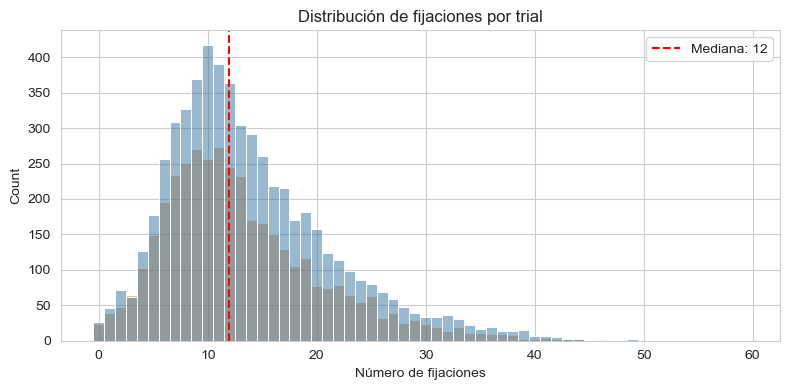

count    9629.00
mean       13.61
std         7.58
min         0.00
25%         8.00
50%        12.00
75%        17.00
max        59.00
Name: n_fixations, dtype: float64


In [19]:
# ---------------------------------------------------------------------------
# Panel 1: Distribución de número de fijaciones por trial
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df_analisis, x='n_fixations', hue='ses',
             discrete=True, ax=ax, palette=COLOR_PALETTE)
ax.axvline(df_analisis['n_fixations'].median(), color='red',
           linestyle='--', label=f'Mediana: {df_analisis["n_fixations"].median():.0f}')
ax.set_title('Distribución de fijaciones por trial')
ax.set_xlabel('Número de fijaciones')
ax.legend()
plt.tight_layout()
plt.show()
print(df_analisis['n_fixations'].describe().round(2))

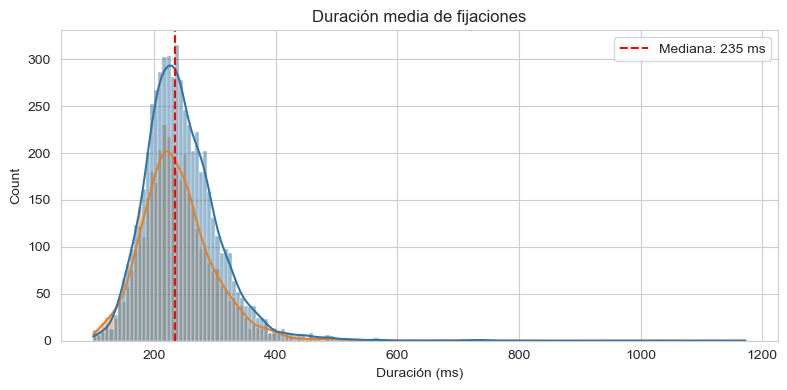

In [20]:
# ---------------------------------------------------------------------------
# Panel 2: Duración media de fijaciones
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
df_v = df_analisis[df_analisis['mean_fix_duration'].notna()]
sns.histplot(data=df_v, x='mean_fix_duration', hue='ses',
             kde=True, ax=ax, palette=COLOR_PALETTE)
ax.axvline(df_v['mean_fix_duration'].median(), color='red',
           linestyle='--', label=f'Mediana: {df_v["mean_fix_duration"].median():.0f} ms')
ax.set_title('Duración media de fijaciones')
ax.set_xlabel('Duración (ms)')
ax.legend()
plt.tight_layout()
plt.show()

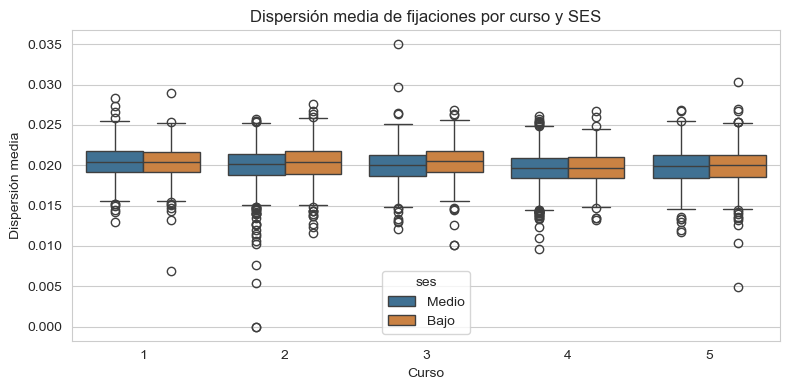

In [21]:
# ---------------------------------------------------------------------------
# Panel 3: Dispersión media por grupo y curso
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
df_v = df_analisis[df_analisis['mean_fixation_dispersion'].notna()]
sns.boxplot(data=df_v, x='curso', y='mean_fixation_dispersion',
            hue='ses', ax=ax, palette=COLOR_PALETTE)
ax.set_title('Dispersión media de fijaciones por curso y SES')
ax.set_xlabel('Curso')
ax.set_ylabel('Dispersión media')
plt.tight_layout()
plt.show()

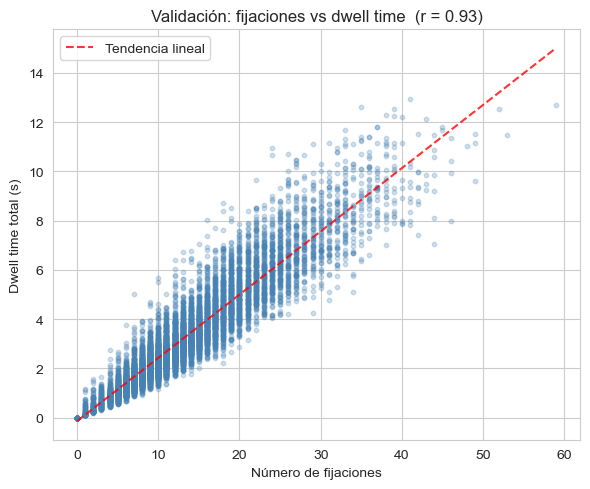

In [22]:
# ---------------------------------------------------------------------------
# Panel 4: Validación — fijaciones vs dwell time total
# (deben correlacionar positivamente si la detección es correcta)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_analisis['n_fixations'], df_analisis['total_dwell_time_s'],
           alpha=0.25, s=10, color='steelblue')

df_v = df_analisis[['n_fixations','total_dwell_time_s']].dropna()
z = np.polyfit(df_v['n_fixations'], df_v['total_dwell_time_s'], 1)
x_line = np.linspace(df_v['n_fixations'].min(), df_v['n_fixations'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), 'r--', alpha=0.8, label='Tendencia lineal')

r = df_v.corr().iloc[0,1]
ax.set_title(f'Validación: fijaciones vs dwell time  (r = {r:.2f})')
ax.set_xlabel('Número de fijaciones')
ax.set_ylabel('Dwell time total (s)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Output

`df_analisis` está listo para análisis estadístico.  
Guardalo opcionalmente como CSV para usarlo en otros notebooks.

In [24]:
# Guardar en CSV (opcional)
OUTPUT_CSV = r'C:\Users\LENOVO L340\Documents\Trabajo\Período actual\Notebooks\data\df_analisis.csv'
df_analisis.to_csv(OUTPUT_CSV, index=False)
print(f'Guardado en {OUTPUT_CSV}')

print(f'df_analisis listo: {df_analisis.shape[0]} trials, {df_analisis.shape[1]} columnas')
print(f'Participantes: {df_analisis["participant_id"].nunique()}')
print(f'Grupos SES: {df_analisis["ses"].value_counts().to_dict()}')


Guardado en C:\Users\LENOVO L340\Documents\Trabajo\Período actual\Notebooks\data\df_analisis.csv
df_analisis listo: 9629 trials, 44 columnas
Participantes: 283
Grupos SES: {'Medio': 5720, 'Bajo': 3909}
